# Fine-tune PhoBERT for Vietnamese NER

**Model:** `vinai/phobert-base` — RoBERTa-based, pre-trained trên 20GB Vietnamese text

**Task:** Token Classification (NER) · BIO format

**Pipeline:**
```
CoNLL file  →  parse  →  tokenize (PhoBERT BPE)  →  align labels
     →  Trainer (fp16, GPU)  →  seqeval metrics  →  training curves  →  save
```

**Entity types:** PERSON · ORGANIZATION · LOCATION · PRODUCT · EVENT · INDUSTRY · MONEY · DATE · PERCENT

In [1]:
# Install dependencies (chỉ cần chạy 1 lần)
import subprocess, sys
pkgs = [
    'transformers>=4.40.0',
    'datasets>=2.18.0',
    'seqeval',
    'evaluate',
    'accelerate>=0.28.0',
    'matplotlib',
    'scikit-learn',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=True)
print('Done.')

Done.


In [1]:
import os, json, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from collections import Counter

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    set_seed,
)
import evaluate
from seqeval.metrics import classification_report as seqeval_report

warnings.filterwarnings('ignore')

# GPU check
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('CUDA không khả dụng — training trên CPU (rất chậm!)')

GPU : NVIDIA GeForce RTX 3070 Laptop GPU
VRAM: 8.0 GB


In [2]:

CFG = {
    # Data
    'data_path'   : 'TXT/ner_conll4.txt',   # CoNLL file từ labeling.ipynb
    'val_split'   : 0.10,                  # 10% validation
    'test_split'  : 0.05,                  # 5% test
    'max_sentences': None,                 # None = dùng tất cả; đặt số nhỏ để debug nhanh

    # Model
    'model_name'  : 'vinai/phobert-base',
    'max_length'  : 256,                   # max token length (PhoBERT max = 256)

    # Training
    'output_dir'  : 'phobert-ner-output',
    'num_epochs'  : 10,
    'batch_size'  : 16,                    # per-device; tăng nếu VRAM còn trống
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.10,                  # 10% steps đầu warmup
    'fp16'        : False,
    'bf16'        : torch.cuda.is_bf16_supported(),  # bf16: ổn định hơn fp16 trên Ampere+
    'seed'        : 42,

    # Early stopping & best model
    'early_stopping_patience' : 2,    # dừng nếu không cải thiện sau N eval
    'early_stopping_threshold': 0.001,# delta tối thiểu để coi là cải thiện

    # Weighted loss
    'weighted_loss'  : True,          # dùng class-weighted CrossEntropy
    'max_class_weight': 10.0,         # cap tối đa tránh gradient bùng nổ

    # Oversampling rare entities
    'oversample_rare'     : True,
    'oversample_ratio'    : 3,        # repeat rare sentences N lần
    'oversample_threshold': 0.05,     # entity type < 5% tổng → 'rare'
}

set_seed(CFG['seed'])
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
print('Config loaded.')
for k, v in CFG.items():
    print(f'  {k:30s}: {v}')

Config loaded.
  data_path                     : TXT/ner_conll4.txt
  val_split                     : 0.1
  test_split                    : 0.05
  max_sentences                 : None
  model_name                    : vinai/phobert-base
  max_length                    : 256
  output_dir                    : phobert-ner-output
  num_epochs                    : 10
  batch_size                    : 16
  learning_rate                 : 2e-05
  weight_decay                  : 0.01
  warmup_ratio                  : 0.1
  fp16                          : False
  bf16                          : True
  seed                          : 42
  early_stopping_patience       : 2
  early_stopping_threshold      : 0.001
  weighted_loss                 : True
  max_class_weight              : 10.0
  oversample_rare               : True
  oversample_ratio              : 3
  oversample_threshold          : 0.05


## 1. Load & Parse CoNLL Data

In [3]:
def parse_conll(filepath: str) -> Tuple[List[List[str]], List[List[str]]]:
    """
    Parse CoNLL format file.
    Hỗ trợ cả tab-separated (token\tlabel) và space-separated (token label).
    Câu cách nhau bằng dòng trống.
    """
    sentences, label_seqs = [], []
    cur_tokens, cur_labels = [], []

    with open(filepath, 'r', encoding='utf-8') as f:
        for raw_line in f:
            line = raw_line.rstrip('\n')
            if not line.strip():
                if cur_tokens:
                    sentences.append(cur_tokens)
                    label_seqs.append(cur_labels)
                    cur_tokens, cur_labels = [], []
                continue
            parts = line.split('\t') if '\t' in line else line.split()
            if len(parts) >= 2:
                cur_tokens.append(parts[0])
                cur_labels.append(parts[-1])   # label ở cột cuối

    if cur_tokens:
        sentences.append(cur_tokens)
        label_seqs.append(cur_labels)

    return sentences, label_seqs


print(f'Loading: {CFG["data_path"]} ...')
all_sentences, all_labels = parse_conll(CFG['data_path'])

# Optional: limit for debugging
if CFG['max_sentences']:
    all_sentences = all_sentences[:CFG['max_sentences']]
    all_labels    = all_labels[:CFG['max_sentences']]

print(f'Tổng câu   : {len(all_sentences):,}')
print(f'Ví dụ [0]  : {all_sentences[0]}')
print(f'Labels [0] : {all_labels[0]}')

# Length distribution
lengths = [len(s) for s in all_sentences]
print(f'\nToken/câu  : min={min(lengths)}, mean={np.mean(lengths):.1f}, max={max(lengths)}, p95={np.percentile(lengths,95):.0f}')
n_long = sum(1 for l in lengths if l > CFG['max_length'])
print(f'Câu dài > {CFG["max_length"]} tokens: {n_long:,} ({n_long/len(lengths)*100:.1f}%) → sẽ bị truncate')

Loading: TXT/ner_conll4.txt ...
Tổng câu   : 27,812
Ví dụ [0]  : ['Motorola', 'chuẩn', 'bị', 'ra', 'mắt', 'phiên', 'bản', 'điện', 'thoại', 'nắp', 'gập', 'Razr', 'giá', 'rẻ', '12', 'triệu', 'đồng']
Labels [0] : ['B-ORGANIZATION', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PRODUCT', 'O', 'O', 'B-MONEY', 'I-MONEY', 'I-MONEY']

Token/câu  : min=3, mean=451.6, max=4457, p95=1327
Câu dài > 256 tokens: 13,704 (49.3%) → sẽ bị truncate


## 2. Label Mapping

In [4]:
# Thu thập tất cả label unique từ data
all_label_set = sorted(set(lbl for seq in all_labels for lbl in seq))

# Đảm bảo 'O' là index 0 để tránh confusion với padding -100
if 'O' in all_label_set:
    all_label_set.remove('O')
    all_label_set = ['O'] + sorted(all_label_set)

label2id = {lbl: i for i, lbl in enumerate(all_label_set)}
id2label = {i: lbl for i, lbl in enumerate(all_label_set)}

NUM_LABELS = len(label2id)

print(f'Số lượng labels: {NUM_LABELS}')
print('\nLabel → ID:')
for lbl, idx in label2id.items():
    print(f'  {idx:3d}  {lbl}')

# Label distribution
print('\nLabel distribution (top 20):')
lbl_counter = Counter(lbl for seq in all_labels for lbl in seq)
for lbl, cnt in lbl_counter.most_common(20):
    pct = cnt / sum(lbl_counter.values()) * 100
    bar = '█' * int(pct)
    print(f'  {lbl:25s} {cnt:>9,}  ({pct:5.1f}%) {bar}')

Số lượng labels: 19

Label → ID:
    0  O
    1  B-DATE
    2  B-EVENT
    3  B-INDUSTRY
    4  B-LOCATION
    5  B-MONEY
    6  B-ORGANIZATION
    7  B-PERCENT
    8  B-PERSON
    9  B-PRODUCT
   10  I-DATE
   11  I-EVENT
   12  I-INDUSTRY
   13  I-LOCATION
   14  I-MONEY
   15  I-ORGANIZATION
   16  I-PERCENT
   17  I-PERSON
   18  I-PRODUCT

Label distribution (top 20):
  O                         11,436,766  ( 91.1%) ███████████████████████████████████████████████████████████████████████████████████████████
  I-ORGANIZATION              224,489  (  1.8%) █
  B-ORGANIZATION              171,624  (  1.4%) █
  B-LOCATION                  116,292  (  0.9%) 
  I-LOCATION                  107,141  (  0.9%) 
  I-MONEY                      60,837  (  0.5%) 
  B-MONEY                      56,324  (  0.4%) 
  B-DATE                       55,115  (  0.4%) 
  I-PERSON                     54,423  (  0.4%) 
  I-INDUSTRY                   54,276  (  0.4%) 
  B-PERSON                     51,368  (

## 3. Train / Val / Test Split

In [5]:
from datasets import Features, Sequence, Value

# Pre-chunk: split sequences longer than max_length into non-overlapping windows.
# Sentences with mean=446 tokens are paragraphs; PhoBERT truncates at 256 anyway,
# so chunking recovers those tokens as additional training samples instead of losing them.
def chunk_sequence(tokens, labels, max_len):
    for start in range(0, max(1, len(tokens)), max_len):
        yield tokens[start:start + max_len], labels[start:start + max_len]

all_sentences_c: List[List[str]] = []
all_labels_c:    List[List[str]] = []
for toks, lbls in zip(all_sentences, all_labels):
    for ct, cl in chunk_sequence(toks, lbls, CFG['max_length']):
        all_sentences_c.append(ct)
        all_labels_c.append(cl)

print(f'Sau chunking: {len(all_sentences_c):,} sequences (từ {len(all_sentences):,} câu gốc)')
lengths_c = [len(s) for s in all_sentences_c]
print(f'Token/seq : min={min(lengths_c)}, mean={sum(lengths_c)/len(lengths_c):.1f}, max={max(lengths_c)}')

# Shuffle + split on chunked data
indices = list(range(len(all_sentences_c)))
random.shuffle(indices)

n_total = len(indices)
n_test  = int(n_total * CFG['test_split'])
n_val   = int(n_total * CFG['val_split'])
n_train = n_total - n_val - n_test

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

# Use from_generator + explicit Features to avoid the fingerprint OOM that
# Dataset.from_dict() triggers (it dill-pickles the entire Arrow table).
ner_features = Features({
    'tokens':   Sequence(Value('string')),
    'ner_tags': Sequence(Value('int32')),
})

def make_hf_dataset(idx_list: List[int]) -> Dataset:
    def _gen():
        for i in idx_list:
            yield {
                'tokens':   all_sentences_c[i],
                'ner_tags': [label2id[l] for l in all_labels_c[i]],
            }
    return Dataset.from_generator(_gen, features=ner_features)

raw_datasets = DatasetDict({
    'train': make_hf_dataset(train_idx),
    'val'  : make_hf_dataset(val_idx),
    'test' : make_hf_dataset(test_idx),
})

print(f'Train : {n_train:,} seqs  ({n_train/n_total*100:.1f}%)')
print(f'Val   : {n_val:,} seqs  ({n_val/n_total*100:.1f}%)')
print(f'Test  : {n_test:,} seqs  ({n_test/n_total*100:.1f}%)')
print(f'\n{raw_datasets}')

Sau chunking: 69,131 sequences (từ 27,812 câu gốc)
Token/seq : min=1, mean=181.7, max=256


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train : 58,762 seqs  (85.0%)
Val   : 6,913 seqs  (10.0%)
Test  : 3,456 seqs  (5.0%)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 58762
    })
    val: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 6913
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3456
    })
})


In [6]:
# ════════════════════════════════════════════════════════════
# Oversampling via WeightedRandomSampler (memory-efficient)
# Không copy data — chỉ gán per-sample weight, Trainer tự resample
# ════════════════════════════════════════════════════════════
from collections import Counter

sample_weights = None  # default: uniform sampling

if CFG.get('oversample_rare', True):
    # ── Đếm entity type frequency trong training set ─────────
    entity_type_counts = Counter()
    for i in train_idx:
        for lbl in all_labels_c[i]:
            if lbl != 'O':
                entity_type_counts[lbl.split('-')[-1]] += 1

    total_entities = sum(entity_type_counts.values())
    thresh = CFG.get('oversample_threshold', 0.05)
    rare_types = {
        t for t, c in entity_type_counts.items()
        if c / total_entities < thresh
    }
    print(f'Entity counts : {dict(entity_type_counts.most_common())}')
    print(f'Rare types (< {thresh*100:.0f}%): {rare_types}')

    # ── Tính per-sample weight (aligned với train_idx order) ──
    # Chunk chứa rare entity → weight = oversample_ratio
    # Chunk bình thường      → weight = 1.0
    # Không copy data → không MemoryError!
    ratio = CFG.get('oversample_ratio', 3)
    sample_weights = []
    n_rare_sents = 0
    for i in train_idx:
        has_rare = any(
            lbl.split('-')[-1] in rare_types
            for lbl in all_labels_c[i] if lbl != 'O'
        )
        if has_rare:
            sample_weights.append(float(ratio))
            n_rare_sents += 1
        else:
            sample_weights.append(1.0)

    n_train = len(train_idx)
    eff_rare_pct = (n_rare_sents * ratio) / (n_train + n_rare_sents * (ratio - 1)) * 100
    print(f'Train sentences         : {n_train:,}')
    print(f'Rare sentences          : {n_rare_sents:,} ({n_rare_sents/n_train*100:.1f}%)')
    print(f'Effective rare pct/epoch: ~{eff_rare_pct:.1f}% (vs {n_rare_sents/n_train*100:.1f}% without)')
    print(f'Memory used             : {len(sample_weights) * 8 / 1024:.1f} KB (weights only)')
else:
    print('Oversampling disabled — using uniform sampling.')


Entity counts : {'ORGANIZATION': 336615, 'LOCATION': 190168, 'MONEY': 99129, 'PERSON': 89713, 'INDUSTRY': 74117, 'DATE': 72466, 'PERCENT': 44577, 'PRODUCT': 41489, 'EVENT': 6312}
Rare types (< 5%): {'EVENT', 'PRODUCT', 'PERCENT'}
Train sentences         : 58,762
Rare sentences          : 17,295 (29.4%)
Effective rare pct/epoch: ~55.6% (vs 29.4% without)
Memory used             : 459.1 KB (weights only)


## 4. Tokenizer & Label Alignment

PhoBERT dùng BPE — 1 word có thể bị tách thành nhiều subword tokens.
- Subword đầu tiên của mỗi word → giữ nguyên label gốc
- Subword tiếp theo → `-100` (ignored trong loss computation)
- Special tokens `[CLS]`, `[SEP]`, `[PAD]` → `-100`

In [7]:
print(f'Loading tokenizer: {CFG["model_name"]} ...')
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Vocab size : {tokenizer.vocab_size:,}')
print(f'Max length : {tokenizer.model_max_length}')
print(f'Fast tokenizer: {tokenizer.is_fast}')

# ── Helper: manual word_ids for slow tokenizers (e.g. PhoBERT) ───────────
def get_word_ids(tokenizer, words: list, max_length: int) -> list:
    """
    Replicate BatchEncoding.word_ids() for slow tokenizers.
    Returns list of len == total tokens; None for special tokens ([CLS]/[SEP]).
    Works by tokenizing each word individually and tracking positions.
    """
    if tokenizer.is_fast:
        enc = tokenizer(words, is_split_into_words=True,
                        truncation=True, max_length=max_length)
        return enc.word_ids()
    # Slow path: tokenize word-by-word
    ids = [None]  # [CLS]
    for word_idx, word in enumerate(words):
        sub = tokenizer.tokenize(word)
        ids.extend([word_idx] * len(sub))
    ids.append(None)  # [SEP]
    # Mirror truncation
    if max_length and len(ids) > max_length:
        ids = ids[: max_length - 1] + [None]
    return ids


# Verify tokenization
sample_tokens = all_sentences[0]
enc = tokenizer(sample_tokens, is_split_into_words=True, truncation=True, max_length=CFG['max_length'])
print(f'\nSample tokenization:')
print(f'  Input words : {sample_tokens}')
print(f'  Word IDs    : {get_word_ids(tokenizer, sample_tokens, CFG["max_length"])}')
print(f'  Subword IDs : {enc.input_ids}')

Loading tokenizer: vinai/phobert-base ...
Vocab size : 64,000
Max length : 1000000000000000019884624838656
Fast tokenizer: False

Sample tokenization:
  Input words : ['Motorola', 'chuẩn', 'bị', 'ra', 'mắt', 'phiên', 'bản', 'điện', 'thoại', 'nắp', 'gập', 'Razr', 'giá', 'rẻ', '12', 'triệu', 'đồng']
  Word IDs    : [None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11, 12, 13, 14, 15, 16, None]
  Subword IDs : [0, 12129, 1580, 45, 40, 641, 894, 618, 462, 7902, 5180, 10174, 24841, 2952, 133, 1455, 445, 113, 80, 2]


In [8]:
def tokenize_and_align_labels(batch: Dict) -> Dict:
    """
    Tokenize + align labels với BPE subword tokens.
    Subword đầu tiên của word → label gốc
    Subword tiếp theo / special tokens → -100 (ignored trong CrossEntropy)
    Compatible với cả fast và slow tokenizer (e.g. vinai/phobert-base).
    """
    tokenized = tokenizer(
        batch['tokens'],
        is_split_into_words=True,
        truncation=True,
        max_length=CFG['max_length'],
    )

    aligned_labels = []
    for i, orig_labels in enumerate(batch['ner_tags']):
        if tokenizer.is_fast:
            word_ids = tokenized.word_ids(batch_index=i)
        else:
            word_ids = get_word_ids(tokenizer, batch['tokens'][i], CFG['max_length'])
        prev_word_id = None
        row = []
        for word_id in word_ids:
            if word_id is None:
                row.append(-100)                   # [CLS], [SEP], [PAD]
            elif word_id != prev_word_id:
                row.append(orig_labels[word_id])   # đầu tiên của word
            else:
                row.append(-100)                   # subsequent subword
            prev_word_id = word_id
        aligned_labels.append(row)

    tokenized['labels'] = aligned_labels
    return tokenized


print('Tokenizing datasets ...')
tokenized_datasets = raw_datasets.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=raw_datasets['train'].column_names,
    desc='Tokenizing',
)

print(tokenized_datasets)

# Verify alignment
sample = tokenized_datasets['train'][0]
ids     = sample['input_ids']
lbl_ids = sample['labels']
tokens_decoded = tokenizer.convert_ids_to_tokens(ids)
print('\nSample alignment (non-padding):')
print(f'  {"Token":20s} {"Label":20s}')
print(f'  {"-"*40}')
for tok, lbl in zip(tokens_decoded[:20], lbl_ids[:20]):
    lbl_str = id2label.get(lbl, f'IGNORE({lbl})')
    print(f'  {tok:20s} {lbl_str}')

Tokenizing datasets ...


Tokenizing:   0%|          | 0/58762 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/6913 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/3456 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 58762
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 6913
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3456
    })
})

Sample alignment (non-padding):
  Token                Label               
  ----------------------------------------
  <s>                  IGNORE(-100)
  ,                    O
  với                  O
  mỗi                  O
  1                    B-MONEY
  triệu                I-MONEY
  đồng                 I-MONEY
  gửi                  O
  tiết                 O
  kiệm                 O
  qua                  O
  VietinBank           O
  i@@                  O
  Pay                  IGNORE(-100)
  khách                O
  hàng                 O
  nhận                 O
  20      

## 5. Model Initialization

In [9]:
print(f'Loading model: {CFG["model_name"]} ...')
model = AutoModelForTokenClassification.from_pretrained(
    CFG['model_name'],
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,  # classifier head sẽ được init lại
)

total_params  = sum(p.numel() for p in model.parameters())
train_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {train_params:,}')
print(f'Num labels       : {NUM_LABELS}')

if torch.cuda.is_available():
    model = model.cuda()
    vram = torch.cuda.memory_allocated(0) / 1024**2
    print(f'VRAM used        : {vram:.0f} MB')

Loading model: vinai/phobert-base ...


Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params     : 134,422,291
Trainable params : 134,422,291
Num labels       : 19
VRAM used        : 513 MB


## 6. Metrics

In [10]:
seqeval_metric = evaluate.load('seqeval')

def compute_metrics(eval_pred) -> Dict:
    """
    Tính precision, recall, F1, accuracy dùng seqeval.
    seqeval hiểu BIO format: đếm entity-level, không phải token-level.
    """
    raw_preds, labels = eval_pred
    preds = np.argmax(raw_preds, axis=2)   # (batch, seq_len)

    true_preds  = [
        [id2label[p] for (p, l) in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(preds, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(preds, labels)
    ]

    results = seqeval_metric.compute(predictions=true_preds, references=true_labels)

    return {
        'precision': results['overall_precision'],
        'recall'   : results['overall_recall'],
        'f1'       : results['overall_f1'],
        'accuracy' : results['overall_accuracy'],
    }


print('Metrics function ready (seqeval — entity-level BIO evaluation).')

Metrics function ready (seqeval — entity-level BIO evaluation).


In [11]:
# ════════════════════════════════════════════════════════════
# Weighted Loss + WeightedLossTrainer
# ════════════════════════════════════════════════════════════
import torch.nn as nn

# ── Tính class weights từ training label distribution ─────────
label_counts_train = Counter()
# Luôn dùng train_idx (oversample dùng sampler, không duplicate indices)
_train_idx_for_weights = train_idx
for i in _train_idx_for_weights:
    label_counts_train.update(all_labels_c[i])

total_train_tokens = sum(label_counts_train.values())
n_cls = NUM_LABELS

# Inverse-frequency với sqrt damping: w_i = sqrt(total / (n * count_i))
raw_weights = np.ones(n_cls)
for lbl, idx in label2id.items():
    cnt = label_counts_train.get(lbl, 1)
    raw_weights[idx] = (total_train_tokens / (n_cls * cnt)) ** 0.5

# Clip + chuẩn hóa về mean = 1
max_w = CFG.get('max_class_weight', 10.0)
raw_weights = np.clip(raw_weights, 0.1, max_w)
class_weights_np = raw_weights / raw_weights.mean()

print('Class weights (inverse-sqrt-frequency):')
for lbl, idx in sorted(label2id.items(), key=lambda x: x[1]):
    cnt = label_counts_train.get(lbl, 0)
    print(f'  {lbl:30s}: weight={class_weights_np[idx]:.3f}  count={cnt:,}')


# ── Custom Trainer: weighted loss + WeightedRandomSampler ──────
class WeightedLossTrainer(Trainer):
    """
    Hai cải tiến:
    1. compute_loss: class-weighted CrossEntropy (giảm bias về O token)
    2. get_train_dataloader: WeightedRandomSampler cho oversampling
       → không copy data vào RAM, không MemoryError
    """
    def __init__(self, *args,
                 class_weights: np.ndarray = None,
                 sample_weights: list = None,
                 **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights  = class_weights
        self._sample_weights = sample_weights  # per-sentence weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        # Upcast về float32 trước khi tính loss:
        # fp16/bf16 logits rất nhỏ → underflow → loss=0 → grad=NaN
        logits  = outputs.logits.float()  # (batch, seq_len, num_labels)

        if self._class_weights is not None:
            weight = torch.tensor(
                self._class_weights, dtype=torch.float32, device=logits.device
            )
            loss_fct = nn.CrossEntropyLoss(weight=weight, ignore_index=-100)
        else:
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)

        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        """Override để dùng WeightedRandomSampler khi có sample_weights."""
        if self._sample_weights is None:
            return super().get_train_dataloader()

        from torch.utils.data import DataLoader, WeightedRandomSampler
        weights_t = torch.tensor(self._sample_weights, dtype=torch.double)
        sampler = WeightedRandomSampler(
            weights=weights_t,
            num_samples=len(weights_t),  # same size, khác phân phối
            replacement=True,
        )
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )


TrainerClass = WeightedLossTrainer if CFG.get('weighted_loss', True) else Trainer
print(f'Trainer class: {TrainerClass.__name__}')


Class weights (inverse-sqrt-frequency):
  O                             : weight=0.057  count=9,717,271
  B-DATE                        : weight=0.824  count=46,919
  B-EVENT                       : weight=2.382  count=1,931
  B-INDUSTRY                    : weight=1.064  count=28,171
  B-LOCATION                    : weight=0.568  count=98,912
  B-MONEY                       : weight=0.817  count=47,732
  B-ORGANIZATION                : weight=0.468  count=145,428
  B-PERCENT                     : weight=1.021  count=30,569
  B-PERSON                      : weight=0.855  count=43,588
  B-PRODUCT                     : weight=1.191  count=22,452
  I-DATE                        : weight=1.117  count=25,547
  I-EVENT                       : weight=2.382  count=4,381
  I-INDUSTRY                    : weight=0.833  count=45,946
  I-LOCATION                    : weight=0.591  count=91,256
  I-MONEY                       : weight=0.787  count=51,397
  I-ORGANIZATION                : weight=0.

## 7. Training

In [12]:
data_collator = DataCollatorForTokenClassification(
    tokenizer,
    padding=True,
    pad_to_multiple_of=8 if CFG['fp16'] else None,  # tối ưu tensor core
)

training_args = TrainingArguments(
    output_dir                  = CFG['output_dir'],
    num_train_epochs            = CFG['num_epochs'],
    per_device_train_batch_size = CFG['batch_size'],
    per_device_eval_batch_size  = CFG['batch_size'] * 2,
    learning_rate               = CFG['learning_rate'],
    weight_decay                = CFG['weight_decay'],
    warmup_ratio                = CFG['warmup_ratio'],
    fp16                        = CFG['fp16'],
    bf16                        = CFG.get('bf16', False),
    max_grad_norm               = 1.0,            # clip gradients — ngăn overflow NaN
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    logging_strategy            = 'steps',
    logging_steps               = 50,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    save_total_limit            = 2,          # giữ 2 checkpoint gần nhất
    report_to                   = 'none',     # tắt wandb/tensorboard
    seed                        = CFG['seed'],
    dataloader_num_workers      = 0,          # Windows: phải để 0
)

# Best model selection: load_best_model_at_end + metric_for_best_model='f1'
# WeightedLossTrainer: dùng class-weighted loss nếu CFG['weighted_loss']=True
trainer = TrainerClass(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized_datasets['train'],
    eval_dataset    = tokenized_datasets['val'],
    tokenizer       = tokenizer,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    class_weights   = class_weights_np if CFG.get('weighted_loss', True) else None,
    sample_weights  = sample_weights,  # None nếu oversample_rare=False
    callbacks       = [EarlyStoppingCallback(
        early_stopping_patience =CFG['early_stopping_patience'],
        early_stopping_threshold=CFG.get('early_stopping_threshold', 0.001),
    )],
)

print('Trainer ready.')
print(f'  Training steps per epoch : {len(tokenized_datasets["train"]) // CFG["batch_size"] + 1:,}')
print(f'  Total training steps     : ~{training_args.num_train_epochs * len(tokenized_datasets["train"]) // CFG["batch_size"]:,}')

Trainer ready.
  Training steps per epoch : 3,673
  Total training steps     : ~36,726


In [13]:
print('=' * 60)
print('START TRAINING')
print('=' * 60)

import time
t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f'\nTraining finished in {elapsed/60:.1f} min')
print(f'  Train loss        : {train_result.training_loss:.4f}')
print(f'  Samples/second    : {train_result.metrics.get("train_samples_per_second", 0):.1f}')
if torch.cuda.is_available():
    print(f'  VRAM peak         : {torch.cuda.max_memory_allocated(0) / 1024**2:.0f} MB')

START TRAINING


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.067700,0.072223,0.792261,0.951557,0.864633,0.980127
2,0.029900,0.044099,0.881048,0.970473,0.923601,0.989532
3,0.022000,0.040113,0.917546,0.971335,0.943675,0.992911
4,0.014700,0.037531,0.918485,0.974016,0.945436,0.993374
5,0.014000,0.039644,0.926885,0.974166,0.949937,0.993636
6,0.010100,0.042589,0.927654,0.973566,0.950056,0.993838
7,0.008000,0.041988,0.934192,0.975366,0.954335,0.994571
8,0.007800,0.042731,0.935590,0.975160,0.954965,0.994549
9,0.007300,0.042772,0.939537,0.974447,0.956674,0.994913
10,0.005600,0.043980,0.938736,0.974972,0.956511,0.994831



Training finished in 120.8 min
  Train loss        : 0.0655
  Samples/second    : 81.1
  VRAM peak         : 3376 MB


## 8. Training Curves

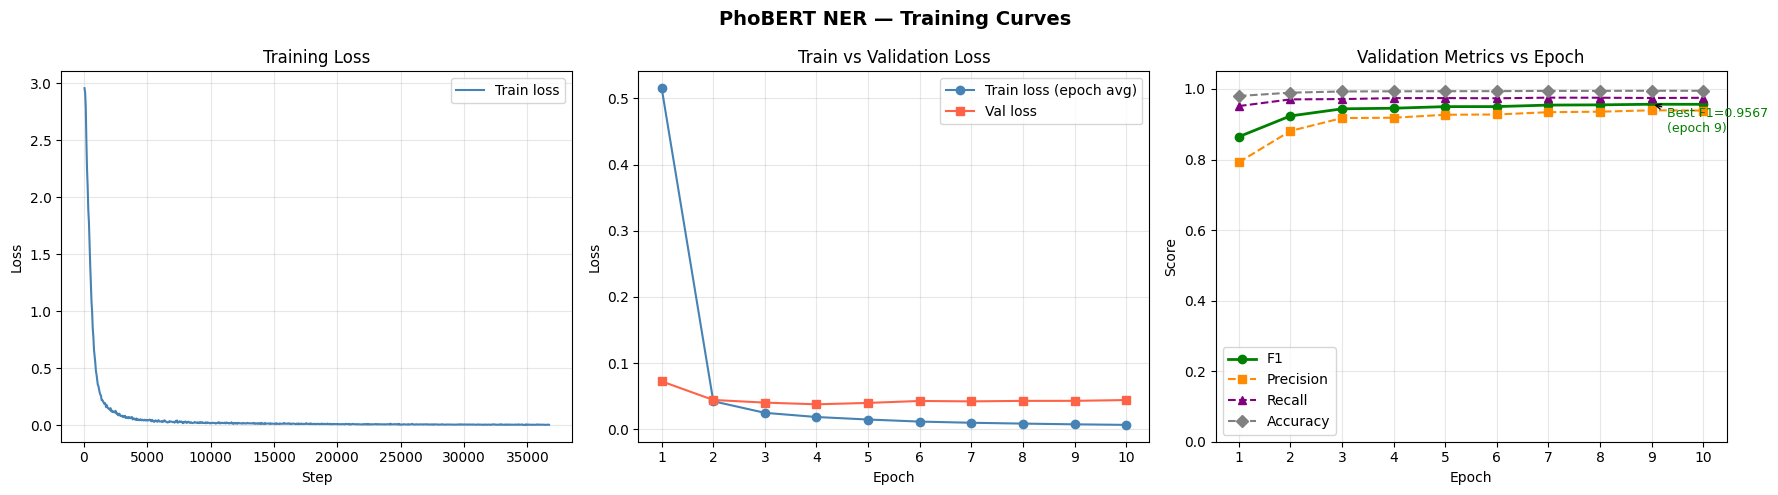

Saved: training_curves.png


In [14]:
log_history = trainer.state.log_history

# Extract training loss (per logging_steps)
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
# Extract validation metrics (per epoch) — bỏ epoch có eval_loss=NaN (fp16 overflow)
eval_logs  = [x for x in log_history
              if 'eval_loss' in x and not np.isnan(x.get('eval_loss', float('nan')))]

train_steps  = [x['step']         for x in train_logs]
train_losses = [x['loss']         for x in train_logs]

eval_epochs  = [x['epoch']        for x in eval_logs]
eval_losses  = [x['eval_loss']    for x in eval_logs]
eval_f1s     = [x.get('eval_f1',    0)  for x in eval_logs]
eval_prec    = [x.get('eval_precision', 0) for x in eval_logs]
eval_rec     = [x.get('eval_recall',    0) for x in eval_logs]
eval_acc     = [x.get('eval_accuracy',  0) for x in eval_logs]

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PhoBERT NER — Training Curves', fontsize=14, fontweight='bold')

# (1) Training Loss vs Step
ax = axes[0]
ax.plot(train_steps, train_losses, color='steelblue', linewidth=1.5, label='Train loss')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# (2) Train Loss (per epoch smoothed) vs Val Loss
ax = axes[1]
if eval_logs:
    # Compute approx train loss per epoch (average over steps in each epoch)
    steps_per_epoch = len(tokenized_datasets['train']) // CFG['batch_size'] + 1
    epoch_train_losses = []
    for ep_idx in range(len(eval_epochs)):
        start = ep_idx * steps_per_epoch
        end   = (ep_idx + 1) * steps_per_epoch
        ep_losses = [x['loss'] for x in train_logs if start <= x['step'] < end]
        epoch_train_losses.append(np.mean(ep_losses) if ep_losses else np.nan)

    ax.plot(eval_epochs, epoch_train_losses, 'o-', color='steelblue', label='Train loss (epoch avg)')
    ax.plot(eval_epochs, eval_losses, 's-', color='tomato', label='Val loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# (3) F1 / Precision / Recall / Accuracy vs Epoch
ax = axes[2]
if eval_logs:
    ax.plot(eval_epochs, eval_f1s,  'o-', color='green',    linewidth=2, label='F1')
    ax.plot(eval_epochs, eval_prec, 's--', color='darkorange', label='Precision')
    ax.plot(eval_epochs, eval_rec,  '^--', color='purple',    label='Recall')
    ax.plot(eval_epochs, eval_acc,  'D--', color='gray',      label='Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Validation Metrics vs Epoch')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Annotate best F1
    best_idx = int(np.nanargmax(eval_f1s))
    ax.annotate(
        f'Best F1={eval_f1s[best_idx]:.4f}\n(epoch {eval_epochs[best_idx]:.0f})',
        xy=(eval_epochs[best_idx], eval_f1s[best_idx]),
        xytext=(eval_epochs[best_idx] + 0.3, eval_f1s[best_idx] - 0.08),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=9, color='green',
    )

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## 9. Evaluation Report

In [15]:
# Evaluate trên test set
print('Evaluating on test set ...')
test_results = trainer.evaluate(tokenized_datasets['test'])

print(f'\n{"="*50}')
print('TEST SET RESULTS')
print(f'{"="*50}')
print(f'  Precision : {test_results["eval_precision"]:.4f}')
print(f'  Recall    : {test_results["eval_recall"]:.4f}')
print(f'  F1        : {test_results["eval_f1"]:.4f}')
print(f'  Accuracy  : {test_results["eval_accuracy"]:.4f}')
print(f'  Loss      : {test_results["eval_loss"]:.4f}')

Evaluating on test set ...



TEST SET RESULTS
  Precision : 0.9417
  Recall    : 0.9744
  F1        : 0.9578
  Accuracy  : 0.9951
  Loss      : 0.0422


In [16]:
# Detailed per-entity report bằng seqeval
print('Generating per-entity classification report ...')

model.eval()
all_true_labels, all_pred_labels = [], []

from torch.utils.data import DataLoader

test_loader = DataLoader(
    tokenized_datasets['test'],
    batch_size=CFG['batch_size'] * 2,
    collate_fn=data_collator,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['labels']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=-1).cpu().numpy()
        labels_np = labels_batch.numpy()

        for pred_row, label_row in zip(preds, labels_np):
            true_seq = [id2label[l] for l in label_row if l != -100]
            pred_seq = [
                id2label[p]
                for (p, l) in zip(pred_row, label_row)
                if l != -100
            ]
            all_true_labels.append(true_seq)
            all_pred_labels.append(pred_seq)

print('\n' + seqeval_report(all_true_labels, all_pred_labels, digits=4))

Generating per-entity classification report ...

              precision    recall  f1-score   support

        DATE     0.9896    0.9977    0.9936      2578
       EVENT     0.7287    0.8704    0.7932       108
    INDUSTRY     0.9256    0.9910    0.9572      1670
    LOCATION     0.9407    0.9721    0.9561      5629
       MONEY     0.9948    0.9984    0.9966      2510
ORGANIZATION     0.8973    0.9506    0.9231      8296
     PERCENT     0.9954    0.9988    0.9971      1715
      PERSON     0.9579    0.9754    0.9666      2521
     PRODUCT     0.9868    0.9963    0.9915      1353

   micro avg     0.9417    0.9744    0.9578     26380
   macro avg     0.9352    0.9723    0.9528     26380
weighted avg     0.9427    0.9744    0.9582     26380



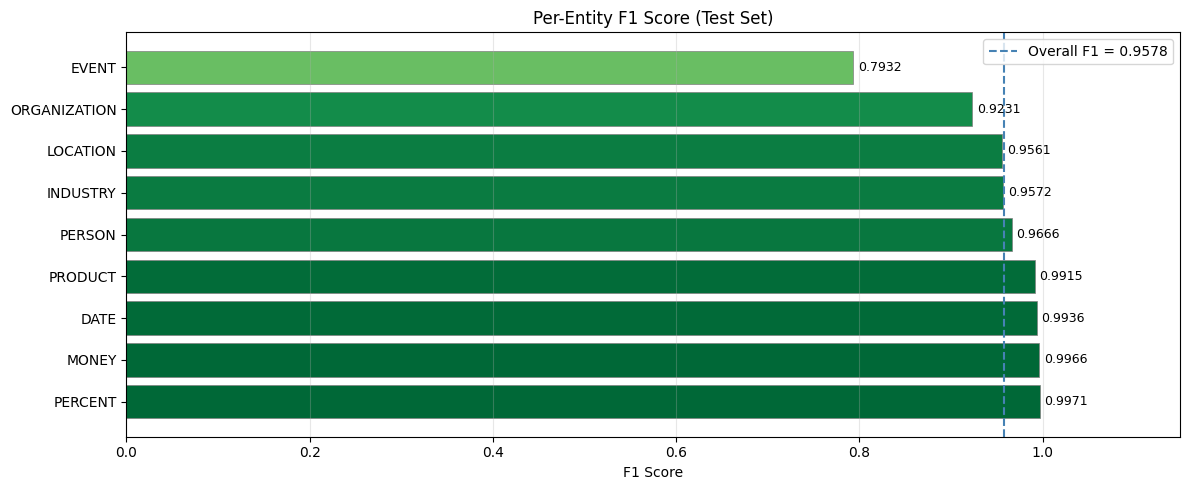

Saved: per_entity_f1.png


In [17]:
# Per-entity F1 bar chart
from seqeval.metrics import f1_score as seqeval_f1
from seqeval.scheme import IOB2
from seqeval.metrics import performance_measure

# Lấy F1 per entity từ seqeval report
report_dict = seqeval_metric.compute(
    predictions=all_pred_labels,
    references=all_true_labels,
)

entity_f1 = {
    k: v['f1']
    for k, v in report_dict.items()
    if isinstance(v, dict) and 'f1' in v
}
entity_f1 = dict(sorted(entity_f1.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    list(entity_f1.keys()),
    list(entity_f1.values()),
    color=plt.cm.RdYlGn([v for v in entity_f1.values()]),
    edgecolor='gray', linewidth=0.5,
)
for bar, val in zip(bars, entity_f1.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlim(0, 1.15)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Entity F1 Score (Test Set)')
ax.axvline(x=report_dict['overall_f1'], color='steelblue', linestyle='--',
           label=f'Overall F1 = {report_dict["overall_f1"]:.4f}')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_entity_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_entity_f1.png')

## 10. Save Model & Tokenizer

In [18]:
SAVE_DIR = Path('phobert-ner-final')
SAVE_DIR.mkdir(exist_ok=True)

# Save best model (đã load lại do load_best_model_at_end=True)
trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))

# Save label mapping
with open(SAVE_DIR / 'label2id.json', 'w', encoding='utf-8') as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)
with open(SAVE_DIR / 'id2label.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in id2label.items()}, f, ensure_ascii=False, indent=2)

# Save config
with open(SAVE_DIR / 'training_config.json', 'w', encoding='utf-8') as f:
    json.dump(CFG, f, ensure_ascii=False, indent=2)

# Save test metrics
metrics_out = {
    'test_precision': test_results['eval_precision'],
    'test_recall'   : test_results['eval_recall'],
    'test_f1'       : test_results['eval_f1'],
    'test_accuracy' : test_results['eval_accuracy'],
    'num_labels'    : NUM_LABELS,
    'per_entity_f1' : entity_f1,
}
with open(SAVE_DIR / 'test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, ensure_ascii=False, indent=2)

print(f'Model saved to: {SAVE_DIR.resolve()}')
print(f'Files:')
for p in sorted(SAVE_DIR.iterdir()):
    print(f'  {p.name:40s} ({p.stat().st_size / 1024:.0f} KB)')

Model saved to: D:\Project\data for DATN\phobert-ner-final
Files:
  added_tokens.json                        (0 KB)
  bpe.codes                                (1109 KB)
  config.json                              (2 KB)
  id2label.json                            (0 KB)
  label2id.json                            (0 KB)
  model.safetensors                        (525110 KB)
  special_tokens_map.json                  (0 KB)
  test_metrics.json                        (1 KB)
  tokenizer_config.json                    (1 KB)
  training_args.bin                        (6 KB)
  training_config.json                     (1 KB)
  vocab.txt                                (874 KB)


## 11. Inference Demo

In [19]:
from transformers import pipeline as hf_pipeline

ner_pipe = hf_pipeline(
    'ner',
    model=str(SAVE_DIR),
    tokenizer=str(SAVE_DIR),
    aggregation_strategy='simple',
    device=0 if torch.cuda.is_available() else -1,
)

test_sentences = [
    "Motorola chuẩn bị ra mắt phiên bản Razr giá rẻ 12 triệu đồng.",
    "Ngày 16/1, ông Roland Staub đến Bình Định cam kết hỗ trợ 50 triệu USD.",
    "Apple ra mắt iPhone 17 Pro Max tại WWDC 2025 với giá 1.199 USD.",
    "BIDV và VPBank công bố lãi suất mới trong năm 2024.",
    "Ngành công nghệ Việt Nam tăng trưởng 6,5% trong quý IV/2024.",
]

print('='*65)
print('INFERENCE DEMO')
print('='*65)
for sent in test_sentences:
    print(f'\nInput: {sent}')
    entities = ner_pipe(sent)
    if entities:
        for ent in entities:
            print(f'  [{ent["entity_group"]:15s}] ({ent["score"]:.3f}) │ "{ent["word"]}"')
    else:
        print('  (no entities detected)')

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


INFERENCE DEMO

Input: Motorola chuẩn bị ra mắt phiên bản Razr giá rẻ 12 triệu đồng.
  [ORGANIZATION   ] (1.000) │ "Motorola"
  [PRODUCT        ] (1.000) │ "Razr"
  [MONEY          ] (1.000) │ "12 triệu"

Input: Ngày 16/1, ông Roland Staub đến Bình Định cam kết hỗ trợ 50 triệu USD.
  [DATE           ] (1.000) │ "Ngày"
  [PERSON         ] (1.000) │ "Roland Staub"
  [LOCATION       ] (1.000) │ "Bình Định"
  [MONEY          ] (1.000) │ "50 triệu"

Input: Apple ra mắt iPhone 17 Pro Max tại WWDC 2025 với giá 1.199 USD.
  [ORGANIZATION   ] (1.000) │ "Apple"
  [PRODUCT        ] (1.000) │ "iPhone 17 Pro Max"
  [EVENT          ] (1.000) │ "WWDC 2025"

Input: BIDV và VPBank công bố lãi suất mới trong năm 2024.
  [ORGANIZATION   ] (1.000) │ "BIDV"
  [ORGANIZATION   ] (1.000) │ "VPBank"
  [DATE           ] (1.000) │ "năm"

Input: Ngành công nghệ Việt Nam tăng trưởng 6,5% trong quý IV/2024.
  [INDUSTRY       ] (1.000) │ "công nghệ"
  [LOCATION       ] (1.000) │ "Việt Nam"
  [PERCENT        ] (1.000

## 12. Load Saved Model (verify)

Kiểm tra model load lại từ file có hoạt động đúng.

In [20]:
# Load lại từ disk
loaded_tokenizer = AutoTokenizer.from_pretrained(str(SAVE_DIR))
loaded_model     = AutoModelForTokenClassification.from_pretrained(str(SAVE_DIR))

print(f'Loaded model   : {loaded_model.config.model_type}')
print(f'Num labels     : {loaded_model.config.num_labels}')
print(f'id2label       : {loaded_model.config.id2label}')

# Quick sanity check
sample_text = "Apple ra mắt iPhone 17 tại Hà Nội."
enc = loaded_tokenizer(sample_text.split(), is_split_into_words=True,
                        return_tensors='pt', truncation=True, max_length=256)
with torch.no_grad():
    out = loaded_model(**enc)
preds = out.logits.argmax(-1)[0]
tokens = loaded_tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
print(f'\nSanity check: "{sample_text}"')
for tok, pred_id in zip(tokens[1:-1], preds[1:-1]):
    lbl = loaded_model.config.id2label[pred_id.item()]
    if lbl != 'O':
        print(f'  {tok:20s} → {lbl}')

print('\nModel loaded và hoạt động đúng!')

Loaded model   : roberta
Num labels     : 19
id2label       : {0: 'O', 1: 'B-DATE', 2: 'B-EVENT', 3: 'B-INDUSTRY', 4: 'B-LOCATION', 5: 'B-MONEY', 6: 'B-ORGANIZATION', 7: 'B-PERCENT', 8: 'B-PERSON', 9: 'B-PRODUCT', 10: 'I-DATE', 11: 'I-EVENT', 12: 'I-INDUSTRY', 13: 'I-LOCATION', 14: 'I-MONEY', 15: 'I-ORGANIZATION', 16: 'I-PERCENT', 17: 'I-PERSON', 18: 'I-PRODUCT'}

Sanity check: "Apple ra mắt iPhone 17 tại Hà Nội."
  Apple                → B-ORGANIZATION
  iPhone               → B-PRODUCT
  17                   → I-PRODUCT
  Hà                   → B-LOCATION
  Nộ@@                 → I-LOCATION
  i.                   → I-LOCATION

Model loaded và hoạt động đúng!
